<a href="https://colab.research.google.com/github/pranita30012005/s2t---t2s/blob/main/NLP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa soundfile matplotlib pyttsx3 SpeechRecognition pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 16.3 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import requests

url = "https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"
zip_path = "speech_data.zip"

# Download
r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("speech_data")

print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [3]:
import requests, zipfile

url = "https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"
zip_path = "speech_data.zip"

# Download
r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

# Extract (THIS IS IMPORTANT)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print("✅ Dataset downloaded and extracted")

✅ Dataset downloaded and extracted


In [4]:
!ls

__MACOSX  mini_speech_commands	sample_data  speech_data  speech_data.zip


In [5]:
!ls speech_data

__MACOSX  mini_speech_commands


In [6]:
!ls speech_data/mini_speech_commands

down  go  left	no  README.md  right  stop  up	yes


In [7]:
!ls speech_data/mini_speech_commands/yes

004ae714_nohash_0.wav  5828dfa2_nohash_0.wav  b31ad508_nohash_0.wav
00f0204f_nohash_0.wav  589bce2c_nohash_0.wav  b36c27c2_nohash_0.wav
012c8314_nohash_0.wav  58df33b5_nohash_0.wav  b41a92a3_nohash_0.wav
0132a06d_nohash_1.wav  58df33b5_nohash_1.wav  b43de700_nohash_0.wav
0132a06d_nohash_3.wav  59c3a7f2_nohash_0.wav  b43de700_nohash_1.wav
0135f3f2_nohash_0.wav  5a3712c9_nohash_0.wav  b49caed3_nohash_0.wav
0135f3f2_nohash_1.wav  5ab63b0a_nohash_0.wav  b49caed3_nohash_3.wav
0137b3f4_nohash_2.wav  5b09db89_nohash_0.wav  b4aa9fef_nohash_1.wav
01648c51_nohash_1.wav  5b09db89_nohash_1.wav  b4aa9fef_nohash_3.wav
019fa366_nohash_1.wav  5b26c81b_nohash_0.wav  b4bef564_nohash_0.wav
01bb6a2a_nohash_4.wav  5c237956_nohash_0.wav  b52bd596_nohash_0.wav
01d22d03_nohash_0.wav  5c39594f_nohash_0.wav  b5552931_nohash_0.wav
01d22d03_nohash_1.wav  5c39594f_nohash_1.wav  b5552931_nohash_1.wav
023808be_nohash_0.wav  5c39594f_nohash_4.wav  b5552931_nohash_3.wav
026290a7_nohash_0.wav  5c8af87a_nohash_0.wav  b5

In [8]:
import os
import librosa

folder = "speech_data/mini_speech_commands/yes"

# Pick first available file
file_name = os.listdir(folder)[0]

audio_path = os.path.join(folder, file_name)

print("Using file:", audio_path)

signal, sr = librosa.load(audio_path)

print("Loaded successfully!")

Using file: speech_data/mini_speech_commands/yes/44dad20e_nohash_0.wav
Loaded successfully!


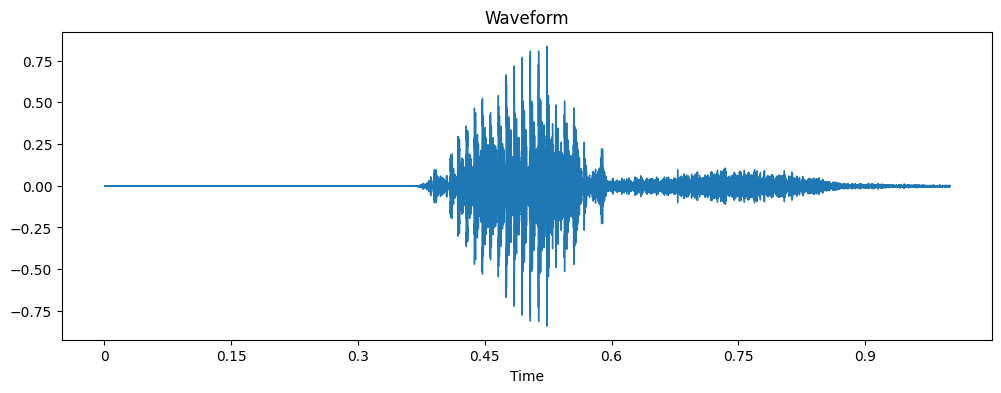

In [9]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Waveform")
plt.show()

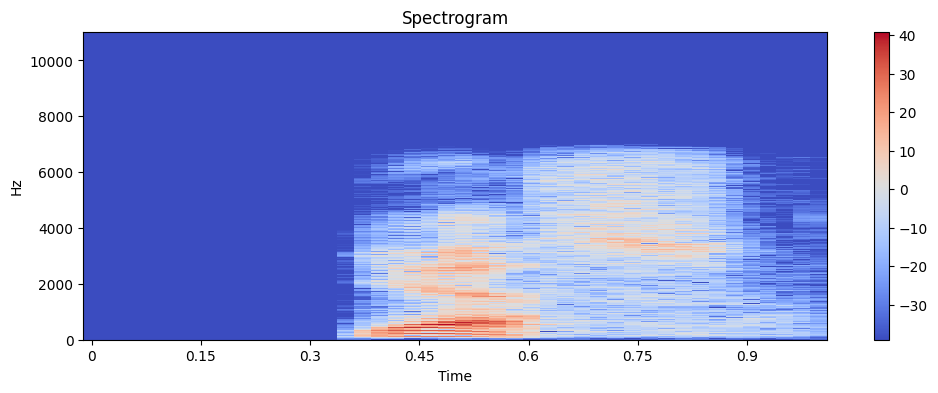

In [10]:
import numpy as np

spectrogram = librosa.stft(signal)
spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram))

plt.figure(figsize=(12, 4))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")
plt.show()

In [11]:
import speech_recognition as sr

recognizer = sr.Recognizer()

# Convert audio to WAV (if needed)
from pydub import AudioSegment
sound = AudioSegment.from_wav(audio_path)
sound.export("converted.wav", format="wav")

# Recognize speech
with sr.AudioFile("converted.wav") as source:
    audio = recognizer.record(source)

try:
    text = recognizer.recognize_google(audio)
    print("Recognized Text:", text)
except:
    print("Could not understand audio")

Recognized Text: yes


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [12]:
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [13]:
from gtts import gTTS
from IPython.display import Audio, display

text = "Hello, my name is pranita."

tts = gTTS(text=text, lang='en')
tts.save("output.mp3")

display(Audio("output.mp3"))

In [14]:
def speech_pipeline(audio_file):
    import speech_recognition as sr
    from gtts import gTTS
    from IPython.display import Audio, display

    recognizer = sr.Recognizer()

    # Speech-to-Text
    with sr.AudioFile(audio_file) as source:
        audio_data = recognizer.record(source)
    try:
        text = recognizer.recognize_google(audio_data)
        print("Speech-to-Text Output:", text)
    except:
        text = "Speech not recognized"
        print(text)

    # Text-to-Speech using gTTS (Colab-compatible)
    tts = gTTS(text=text, lang='en')
    tts.save("pipeline_output.mp3")
    display(Audio("pipeline_output.mp3"))

In [15]:
import speech_recognition as speech_rec

In [16]:
import librosa

signal, sr = librosa.load(audio_path)

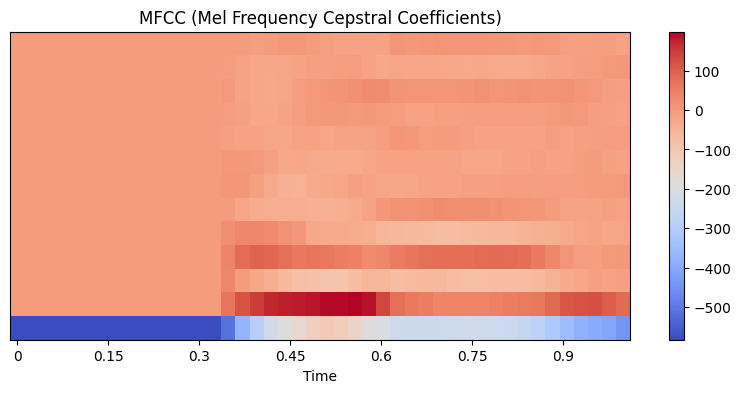

In [17]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC (Mel Frequency Cepstral Coefficients)")
plt.show()

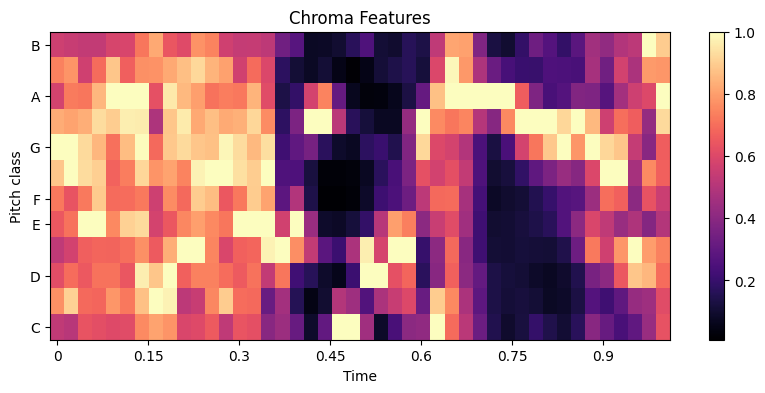

In [18]:
chroma = librosa.feature.chroma_stft(y=signal, sr=sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(chroma, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title("Chroma Features")
plt.show()

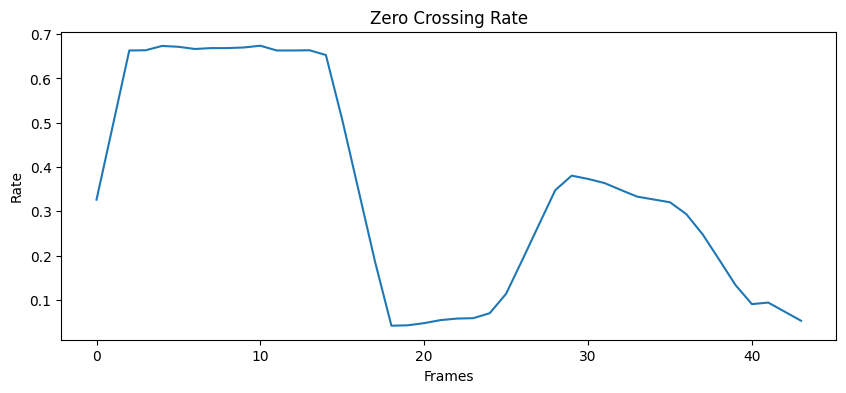

In [19]:
zcr = librosa.feature.zero_crossing_rate(signal)

plt.figure(figsize=(10,4))
plt.plot(zcr[0])
plt.title("Zero Crossing Rate")
plt.xlabel("Frames")
plt.ylabel("Rate")
plt.show()

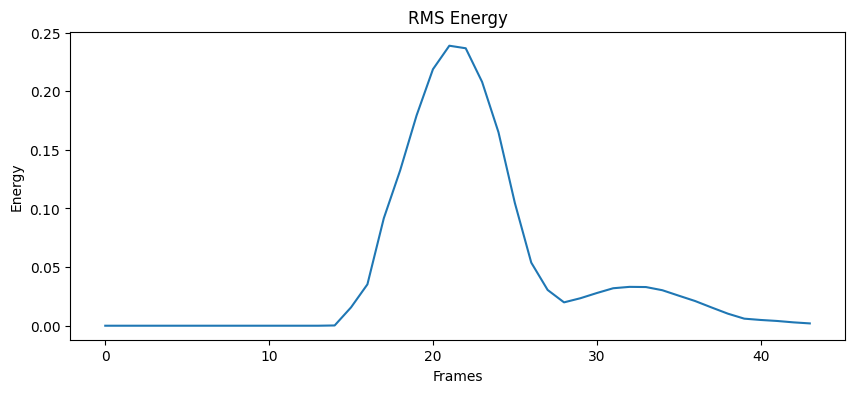

In [20]:
rms = librosa.feature.rms(y=signal)

plt.figure(figsize=(10,4))
plt.plot(rms[0])
plt.title("RMS Energy")
plt.xlabel("Frames")
plt.ylabel("Energy")
plt.show()

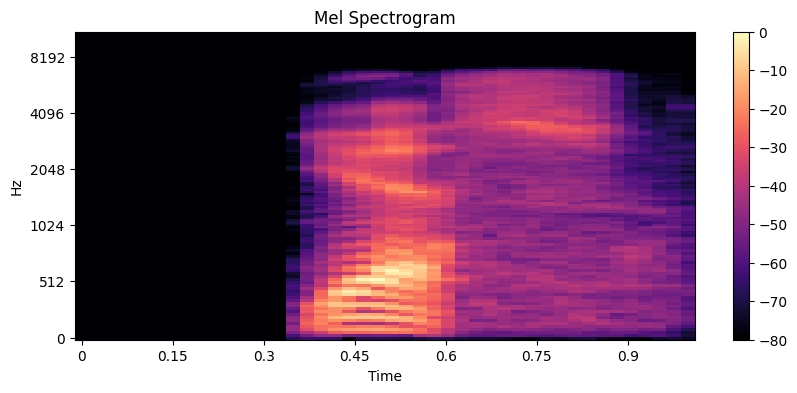

In [21]:
mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

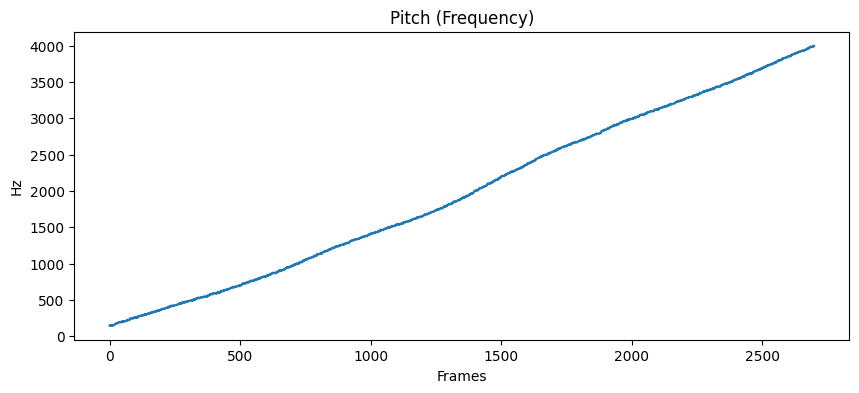

In [22]:
import numpy as np

pitches, magnitudes = librosa.piptrack(y=signal, sr=sr)

pitch_values = pitches[magnitudes > np.median(magnitudes)]

plt.figure(figsize=(10,4))
plt.plot(pitch_values)
plt.title("Pitch (Frequency)")
plt.xlabel("Frames")
plt.ylabel("Hz")
plt.show()

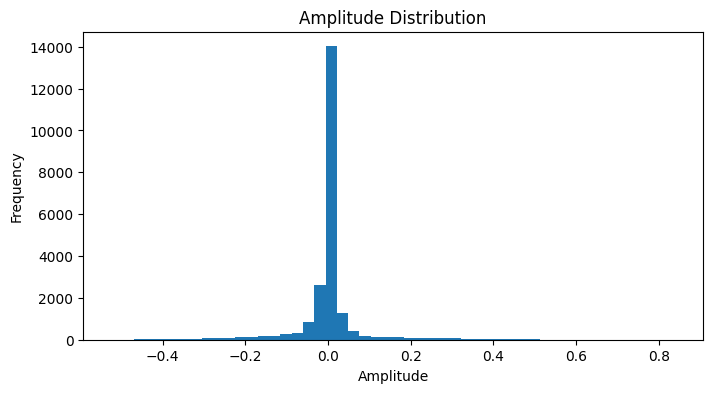

In [23]:
plt.figure(figsize=(8,4))
plt.hist(signal, bins=50)
plt.title("Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.show()

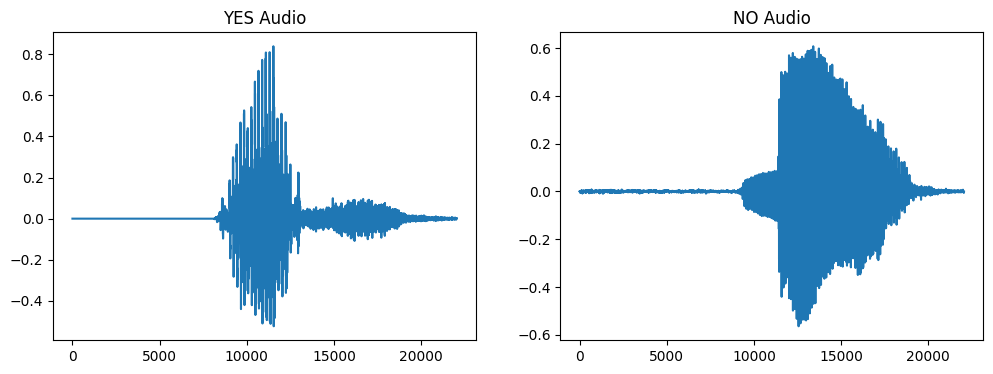

In [24]:
import os

yes_file = os.listdir("mini_speech_commands/yes")[0]
no_file = os.listdir("mini_speech_commands/no")[0]

yes_signal, _ = librosa.load(f"mini_speech_commands/yes/{yes_file}")
no_signal, _ = librosa.load(f"mini_speech_commands/no/{no_file}")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(yes_signal)
plt.title("YES Audio")

plt.subplot(1,2,2)
plt.plot(no_signal)
plt.title("NO Audio")

plt.show()

In [25]:
print("Feature Summary:")
print("Signal Length:", len(signal))
print("Sample Rate:", sr)
print("Mean Amplitude:", signal.mean())
print("Max Amplitude:", signal.max())
print("Min Amplitude:", signal.min())

Feature Summary:
Signal Length: 22050
Sample Rate: 22050
Mean Amplitude: -1.1958e-05
Max Amplitude: 0.839298
Min Amplitude: -0.524068
